# 5.1 시대를 초월하는 모델링 학습
케플러는 데이터에 부합하면서도 최대한 단순한 기하 모델을 추론하려고 노력함
- 모든 행성의 궤도는 타원이며 두 초점 중 하나에 태양이 위치한다.

1. 행성들의 위성을 관찰하여 타원 궤도의 모양과 크기를 측정.
2. 해당 데이터를 기반으로 이 두 파라미터를 계산하여 행성 전체 이동 경로를 파악.
3. 제 2법칙을 발견한 후 관측을 통해 행성이 언제 어떤 지점에 머무를 것인지도 예측
---
- 후보 모델들(타원 모양)
- 데이터들(케플러의 제1+제2 법칙-타원 이심률,크기 등)
- 추론 결과(곡선을 찾아 많은 위치를 발견)
- 검증(계산된 위치와 관촬된 위치와 동일한지 점검)
---
이 과정은 실제로 데이터에 맞춰가는 과정과 데이터로부터 학습하는 알고리즘을 만드는 과정과 같다.

여기에는 항상 데이터로부터 평가되는 알 수 없는 파라미터를 가진 함수가 있음을 전제.

이 함수를 '모델'이라고 일컫는다.


해당 '학습 기법'장에는 일반 함수의 적합(fitting)을 자동화하는 방법에 대해 다룬다.

이는 딥러닝의 핵심이고 우리가 말하는 일반 함수며, 파이토치는 이 과정을 최대한 단순하고 투명하게 만들어준다.

첫 번째 원리로부터 학습 알고리즘의 동작 방식을 이해하고 더 복잡한 모델로 넘어가보자.

## 5.2 학습은 파라미터 추정에 불과하다
새로운 데이터에 대해 잘 예측할 수록 어떻게 데이터를 얻고, 모델을 고르고, 모델의 파라미터를 추정할지를 배운다.

입력 및 입력에 대응하는 출력인 `실측 자료(ground truth)`와 `가중치 초깃값`이 주어졌을 때, 모델에 `입력 데이터`가 들어가고(순방향) `실측값`과 `출력 결과값`을 **비교**해서 **오차를 계산**한다.

그리고 모델의 `파라미터(가중치)`를 최적화하기 위해 가중치를 `오차값에 따라 일정 단위`만큼(파라미터별 오류의 기울기(gradient))변경한다.

이 변경 값은 합성 함수(`역방향`)의 미분값을 연속으로 계산하는 규칙(`chain rule`)을 통해 정해진다.

이렇게 하면 `오차가 줄어드는 방향`으로 가중치값이 조정된다. 이 과정은 학습 때 사용하지 않았던 데이터에 대한 `출력 값과 실측 값과의 오류`가 일정 수준 이하로 떨어질 때 까지 **반복**

*ground truth 란 특정 질문이나 문제에 대한 실제 또는 정확한 답을 의미(즉, 신뢰할 수 있는 정보로 수동으로 레이블을 지정하는 등)


### 기울기의 원리
기울기'의 원리가 어떻게 가중치 조정에 사용되는지 좀 더 자세히 설명해 드릴게요.

우리가 모델의 오차를 최소화하는 것이 목표라고 했죠? 이 오차는 모델의 파라미터(가중치) 값에 따라 달라집니다. 즉, 가중치 값을 변경하면 오차가 커질 수도 있고 작아질 수도 있습니다.

여기서 '기울기'는 가중치 값을 아주 조금 변경했을 때 오차가 얼마나, 그리고 어느 방향으로 변하는지를 나타내는 값입니다.

---
간단한 예시를 들어봅시다.

우리가 1차 함수 y = ax + b로 어떤 데이터를 설명하려고 합니다. 여기서 a와 b가 모델의 파라미터(가중치)입니다. 우리는 실제 데이터의 y값과 모델이 예측한 y값 사이의 '오차'를 최소화하려고 합니다.

1. 오차 함수: 우리는 오차를 계산하는 함수를 만듭니다. 예를 들어, 실제 y값과 예측된 y값의 차이를 제곱한 값의 평균을 사용할 수 있습니다. 이 오차 함수는 파라미터 a와 b에 따라 값이 달라지는 함수입니다.

2. 기울기 계산: 이제 각 파라미터(a와 b)에 대해 오차 함수의 '기울기'를 계산합니다.
- a에 대한 기울기는 a 값을 아주 조금 변경했을 때 오차 함수 값이 얼마나 변하는지를 나타냅니다.
- b에 대한 기울기는 b 값을 아주 조금 변경했을 때 오차 함수 값이 얼마나 변하는지를 나타냅니다.

3. 기울기의 의미:
- 만약 a에 대한 기울기가 양수라면, a 값을 증가시키면 오차가 증가하고, a 값을 감소시키면 오차가 감소한다는 뜻입니다.
- 만약 a에 대한 기울기가 음수라면, a 값을 증가시키면 오차가 감소하고, a 값을 감소시키면 오차가 증가한다는 뜻입니다.
- 기울기가 0이라면, 현재 a 값 근처에서는 a 값을 아주 조금 변경해도 오차에 큰 변화가 없다는 뜻이며, 오차가 최소화되는 지점에 가까워졌을 가능성이 높습니다.

4. 가중치 조정: 우리는 오차를 줄이는 방향으로 가중치를 조정하고 싶습니다. 따라서 계산된 기울기를 활용합니다.
- a에 대한 기울기가 양수이면, 오차를 줄이기 위해 a 값을 감소시킵니다.
- a에 대한 기울기가 음수이면, 오차를 줄이기 위해 a 값을 증가시킵니다.

즉, 가중치에 '기울기의 반대 방향'으로 이동하는 것이 오차를 줄이는 방향이 됩니다. 이때 '일정 단위'는 학습률(learning rate)이라고 불리는 값으로, 얼마나 크게 가중치를 조정할지를 결정합니다.

이처럼 기울기는 마치 산에서 가장 낮은 곳(오차가 최소인 곳)을 찾아 내려가는 길잡이 역할을 합니다. 기울기는 현재 위치에서 어느 방향으로 발을 내디뎌야 가장 빠르게 아래로 내려갈 수 있는지를 알려주는 것입니다.

딥러닝에서는 이 기울기를 효율적으로 계산하기 위해 '역전파(Backpropagation)'라는 알고리즘을 사용하며, 이는 'chain rule'을 통해 이루어집니다. 복잡한 모델에서도 각 파라미터가 최종 오차에 얼마나 영향을 미치는지 효율적으로 계산하여 오차를 줄이는 방향으로 가중치를 업데이트할 수 있습니다.

### bias (편향값)가 왜 필요한가?

bias가 없다면 모델은 항상 원점(0,0)을 지나야만 하는 직선을 표현하게 됩니다. 즉, 모델은 t_c = w * t_u와 같은 형태가 된다.

하지만 실제 데이터는 항상 원점을 지나지 않는다. 우리가 가지고 있는 온도 데이터를 산점도로 그렸을 때, 그 점들이 정확히 (0,0)을 지나는 직선 위에 놓여 있지 않을 가능성이 높다.

bias는 모델이 원점을 지나지 않는 다양한 위치의 직선을 표현할 수 있도록 해준다.

bias 값을 조절함으로써 모델의 직선을 상하로 이동시킬 수 있다.

```
bias가 양수이면 직선이 위로 이동합니다.
bias가 음수이면 직선이 아래로 이동합니다.
bias가 0이면 직선이 원점을 지납니다.
```

즉, bias는 모델이 데이터를 더 정확하게 '맞추기' 위해 필요한 추가적인 조정값이라고 생각하면 됩니다. w가 직선의 기울기를 결정한다면, b는 직선의 y축 절편(위치)을 결정하는 역할을 합니다

## 5.2.1 온도 문제
온도계 단위가 없다는 점의 문제를
1. 선호하는 단위를 사용해 온도계를 읽고 일치하는 온도를 기록한 데이터셋을 만든 후,
2. 학습을 위한 모델을 하나 골라 오차가 충분히 낮아질 때 까지 반복적으로 가중치를 조절하여 우리가 이해하는 온도 단위로 새로운 눈금을 해석해보자.



## 5.2.2 데이터 수집
섭씨 단위의 온도 데이터 노트를 만들고 새 온도계로 측정하면서 데이터를 수집.

In [1]:
import numpy as np
import torch
torch.set_printoptions(edgeitems=2, threshold=50)

In [2]:
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c) # 섭씨 온도 값
t_u = torch.tensor(t_u) # 모르는 단위 값

t_c 값은 섭씨 온도 값, t_u 값은 우리가 모르는 단위 값이다.

이 두 값은 온도계에서 얻었고 어느정도 노이즈가 있는 측정값이다. 편의를 위해 텐서에 넣었다.

## 5.2.3 데이터 시각화

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


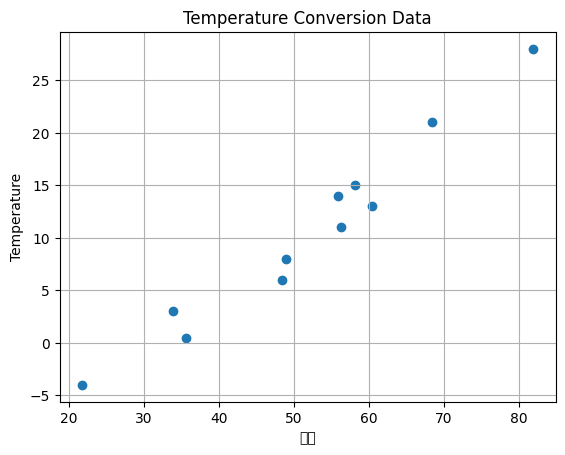

In [3]:
import matplotlib.pyplot as plt
import torch

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

# matplotlib를 사용하여 산점도 그리기
plt.scatter(t_u.numpy(), t_c.numpy())
plt.xlabel("측정")
plt.ylabel("Temperature")
plt.title("Temperature Conversion Data")
plt.grid(True)
plt.show()

이 데이터는 선형 모델을 따른다.

## 5.2.4 먼저 선형 모델을 골라 시도해보기
두 측정 값 사이에서 변환하는 역할을 해줄 모델 중 가장 단순한 것을 가정.

둘사이에 선형 관계가 존재할지 모르니

t_u에 어떤 값을 곱하고 상수를 더하면 섭씨 단위의 온도값을 얻을지 모르겠다.

`t_c = w * t_u + b`

해당 가정으로 최종 모델이 잘 동작하는지 확인한다. 가중치(weight)와 편향값(bias)을 각각 w와 b로 부르자. 이 두용어는 이미 선형 스케일링(확대/축소)에서 일반적으로 사용하는 표현이다.

우리 모델의 파라미터인 w와 b를 데이터 기반으로 추정하여 모델을 통해 t_u로 표기한 알 수 없는 온도값을 섭씨 단위로 측정한 실측 값에 최대한 가깝도록 만들게 된다.

이 파라미터의 값을 잘 추정해서 측정된 값과 예측값인 출력값 사이의 오차가 최대한 작아지게 만든다.

오차 측정을 정의하는 방법은 "손실 함수(loss function)"이라고 불리는 측정 함수를 만들되 오차가 높으면 함수의 출력값도 높아지도록 정의한다.

즉, 완벽하게 일치할 경우 함수의 출력값을 가능한 한 작게 만들어 손실 함수의 값이 최소인 지점에서 `(w)weight`와 `(b)bias`를 찾는 과정을 "최적화 과정" 이라고 한다.

# 5.3 손실을 줄이기 위한 방안
### 손실함수(비용함수)
학습 과정이 최소화하고자 하는 단일 값을 계산하는 함수.

일반적으로 `훈련 샘플`로부터 기대하는 `출력값과 모델`이 샘플에 대해 `실제 출력한 값 사이의 차이`를 계산한다.

우리의 경우에서 손실 함수는 모델이 출력한 온도인 `t_p` 와 계측한 값과의 차이인 `t_p - t_c` 이다.

손실함수는 t_p 가 t_c 보다 크든 작든 항상 양수의 차이가 나오게 하여 t_p 가 t_c 에 맞춰가는 데 사용할 수 있게 한다.

```
|t_p - t_c| 혹은 (t_p - t_c)^2
```
을 사용하여 어떤 형태를 사용하는지에 따라 특정 오차를 강조하거나 무시하게 된다.

"훈련 샘플로부터 나오는 오차 중 어떤 경우를 우선해서 보완해나갈 것인지를 결정"

-> 파라미터 조정은 가중치가 큰 샘플을 우선적으로 보정

두 손실 함수 모두 최소 오차 0, 어느 방향이로든 `예측값이 실젯값보다 커지면` 오차도 단조적으로 증가.

`그래프의 상승 기울기` 역시 최솟값으로 부터 단조적으로 증가하여 둘 다 `볼록` 하다.

손실이 모델 파라미터의 볼록 함수인 경우는 특수한 알고리즘을 통해 매우 효과적으로 최솟값을 찾을 수 있기 때문에 다루기가 매우 좋다.
### `(t_p - t_c)^2`
은 t_p가 t_c인 경우, 손실값의 제곱에 대한 t_p 로의 미분값은 0
### `|t_p - t_c|`
은 절대값을 사용한 경우는 우리가 수렴하고자 하는 경우에 미분값을 정의할 수 없다.

그리하여 제곱을 한 형태가 최솟값 근처에서 더 잘 동작할 것 같다.

제곱을 사용한 차이는 잘못된 결과에 더 많은 불이익을 준다는 사실이다.

오차 보정에 우선순위를 주도록 동작한다.


### |t_p - t_c| 혹은 (t_p - t_c)^2  차이에 대한 자세한 설명

두 가지 오차 측정 방식의 기본:

우리의 목표는 예측값 (t_p)과 실제 값 (t_c) 사이의 차이를 줄이는 것입니다. 이 차이를 '오차'라고 부르고, 이 오차를 계산하는 함수를 '손실 함수'라고 합니다. 손실 함수는 오차가 클수록 큰 값을 반환해야 합니다.

1. 절댓값 오차 (|t_p - t_c|):

예측값과 실제 값의 '거리'를 직접적으로 계산합니다.
예를 들어, 오차가 +3이든 -3이든 절댓값은 3이 됩니다. 오차의 크기만 중요하게 봅니다.
t_p와 t_c가 같을 때 (오차가 0일 때) 손실값은 0으로 최소가 됩니다.
t_p가 t_c에서 멀어질수록 손실값은 선형적으로 증가합니다. 그래프로 그리면 V자 모양이 됩니다.

2. 제곱 오차 ((t_p - t_c)^2):

예측값과 실제 값의 차이를 제곱합니다.
예를 들어, 오차가 +3이면 제곱 오차는 9, 오차가 -3이면 제곱 오차도 9가 됩니다. 부호와 관계없이 오차의 크기가 제곱되어 반영됩니다.
t_p와 t_c가 같을 때 (오차가 0일 때) 손실값은 0의 제곱인 0으로 최소가 됩니다.
t_p가 t_c에서 멀어질수록 손실값은 제곱에 비례하여 증가합니다. 그래프로 그리면 U자 모양(포물선)이 됩니다.

#### 결론
큰 오차를 가진 데이터 샘플에 대해 더 민감하게 반응하고, 이를 줄이는 데 우선순위 =  '잘못된 결과에 더 많은 불이익을 준다', '오차 보정에 우선순위를 주도록 동작한다'는 것이 바로 이 의미와 동일

---

### "최소 오차 0, 예측값이 실젯값보다 커지면 오차도 단조적으로 증가" 의 의미:

이 말은 두 손실 함수 모두 예측값이 실제 값과 정확히 일치할 때 오차가 가장 작아지고 (0), 예측값이 실제 값에서 어느 방향으로든 (크든 작든) 멀어질수록 오차가 계속 커진다는 뜻입니다. 헷갈리는 중간값 없이 한쪽 방향으로만 값이 증가한다는 의미에서 '단조적으로 증가'한다고 표현했습니다.

---

### "그래프의 상승 기울기 역시 최솟값으로 부터 단조적으로 증가하여 둘 다 볼록 하다" 의 의미:

이 부분은 그래프의 모양에 대한 설명입니다.

- 볼록 함수: 그래프가 아래로 볼록한 모양을 가진 함수를 말합니다. U자나 V자처럼 생긴 그래프는 볼록 함수입니다. 볼록 함수의 장점은 가장 낮은 지점(최솟값)이 하나뿐이라는 것입니다. 마치 그릇처럼, 어디에서 시작하든 아래쪽으로 계속 내려가다 보면 언젠가는 바닥(최솟값)에 도달할 수 있습니다.

- 상승 기울기: 그래프에서 최솟값을 기준으로 오른쪽으로 갈수록 그래프의 기울기가 양수이고 점점 커진다는 의미입니다. 왼쪽으로 갈수록 기울기는 음수이고 절댓값이 커집니다. 두 함수 모두 최솟점(오차 0인 곳)에서 멀어질수록 오차가 커지므로 이런 특징을 가집니다.

손실 함수가 '볼록 함수'이면 우리가 원하는 최솟값을 찾기가 훨씬 수월합니다. '기울기'를 따라 내려가는 방법(경사 하강법)을 사용했을 때, 지역 최솟값에 빠질 염려 없이 전역 최솟값(진정한 최솟값)을 찾을 가능성이 높기 때문입니다.

---



## 5.3.1 파이토치로 문제 풀어보기


학습 과정을 설정하고 실제 데이터를 넣어보자.

In [4]:
def model(t_u, w, b):
  return w * t_u + b

t_u, w, b 는 순서대로 입력 텐서, 가중치 파라미터, 편향값 파라미터다.

파라미터: 파이토치 스칼라값, 행렬곱 연산은 텐서를 반환하기 위해 브로드캐스팅 사용

평균제곱손실(mean square loss) 손실함수를 작성해보자

In [5]:
# 손실함수 작성
def loss_fn(t_p, t_c):
  squared_diffs = (t_p - t_c)**2
  return squared_diffs.mean()

In [6]:
# 파라미터를 초기화하고 모델 호출
w = torch.ones(())
b = torch.zeros(())

t_p = model(t_u, w, b)
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [7]:
# 손실값 체크
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

# 5.2 경사를 따라 내려가기
경사 하강(gradient descent) 알고리즘을 사용해 파라미터 관점에서 손실 함수를 최적화 한다.

경사 하강은 수백만 개의 파라미터를 가진 대규모 신경망에도 놀라울 정도로 쉽게 확장 적용할 수 있다.



## 5.4.1 손실 줄이기
경사 하강은 각 파라미터와 관련해 손실의 변화율을 계산해 손실이 줄어드는 방향으로 파라미터 값을 바꿔나간다. w와 b값을 아주 조금 늘리거나 줄여서 그 사이에 손실값이 얼마나 변하는지 확인해보자


In [8]:
delta = 0.1

loss_rate_of_change_w = \
  (loss_fn(model(t_u, w + delta, b), t_c) -
   loss_fn(model(t_u, w - delta, b), t_c)) / (2.0 * delta)

이 코드는 현재 w와 b값에서 특정 단위만큼 w가 증가했을 때의 손실이 변하게 만든다.

값이 줄어들면 w를 더 늘려서 손실을 최소화, 값이 늘어나면 반대로 w를 줄여서 손실을 최소화

손실의 변화 비율에 비례해서 w를 바꾸는 편이 좋다. 이는 손실 함수가 여러 파라미터를 가질수록 더 그렇다. 일반적으로 파라미터 값은 손실값 변화에 영향이 많이 미치기에 서서히 변경하는 것이 좋다.

현재 w값의 변화율이 얼마만큼 바꿔갈 것인지 스케일링 비율은 learning_rate(학습률) 변수명을 사용한다.

In [9]:
learning_rate = 1e-2

w = w - learning_rate * loss_rate_of_change_w

In [10]:
# bias
loss_rate_of_cahnge_b = \
  (loss_fn(model(t_u, w, b + delta), t_c) -
   loss_fn(model(t_u, w, b - delta), t_c)) / (2.0 * delta)

b = b - learning_rate * loss_rate_of_cahnge_b

이런 식의 파라미터 조정으로 평가를 반복함으로써 주어진 데이터에 대해 손실 계산값이 최소로 떨어지는 최적의 파라미터 값으로 수렴하게 되는 것이다.

## 5.4.2 분석
w와 b의 인접 영역에서 손실함수의 동작 방식을 조사: 모델과 손실값을 반복적으로 평가하며 변화율을 계산하는 것을 파라미터가 많은 모델로 확장하는 것은 어렵다.

delta를 0.1로 뒀지만, 손실함수의 모양에 따라 달라진다.

지정한 delta 값에 비해 손실값이 너무 빠르게 변한다면 최소화하기 위해 어떤 방향으로 파라미터를 조정할지 판단이 쉽지않다.


### 기울기
두 개 이상의 파라미터를 가진 모델에서는 각 파라미터에 대한 손실함수의 편미분을 구하고, 이 편미분 값들을 편미분 벡터에 넣음

### 미분 계산하기
미분 계산은 연쇄 규칙을 적용하여 입력(모델의 출력값)에 대한 손실 함수의 미분을 계산해 파라미터에 대한 모델의 미분을 곱한다.

In [11]:
# d loss_fn / d w = d loss_fn / d t_p * d t_p / d w
# 우리 모델은 손실함수는 제곱의 합이기에 손실 함수 식을 기억해 코드로 작성
# 손실함수 작성
def loss_fn(t_p, t_c):
  squared_diffs = (t_p - t_c)**2
  return squared_diffs.mean()

In [12]:
# d x^2 / d x = 2 x 코드
def dloss_fn(t_p, t_c):
  dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)
  return dsq_diffs

### 모델에 미분 적용하기


In [13]:
def model(t_u, w, b):
  return w * t_u + b  # 가중치x입력값+편향값

In [14]:
# 미분 구하기
def dmodel_dw(t_u, w, b):
  return t_u

def dmodel_db(t_u, w, b):
  return 1.0

### 경사 함수 정의하기
모두 합쳐 w와 b에 대한 손실값의 미분을 반환


In [15]:
def grad_fn(t_u, t_c, t_p, w, b):
  dloss_dtp = dloss_fn(t_p, t_c)
  dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
  dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
  return torch.stack([dloss_dw.mean(), dloss_db.mean()]) # 합 계산은 파라미터 모델 전체 입력 벡터에 대해 적용한 브로드캐스팅의 역순

## 5.4.3 모델 적합을 위한 반복
파라미터를 위한 임시 값~고정된 횟수만큼 반복, w와 b가 변하지 않을 때 까지 조정

정한 횟수만큼만 반복

### 훈련 루프
에포크(Epoch): 훈련 샘플을 가지고 반복적으로 파라미터를 조정하는 훈련의 한 단위


In [16]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
  for epoch in range(1, n_epochs + 1):
    w, b = params

    t_p = model(t_u, w, b) # 순방향 전달
    loss = loss_fn(t_p, t_c) # 손실 함수
    grad = grad_fn(t_u, t_c, t_p, w, b) # 역방향 전달

    params = params - learning_rate * grad # 파라미터 조정

    print('Epoch %d, Loss %f' % (epoch, float(loss)))

  return params

In [17]:
# 훈련 루프 실행
training_loop(
    n_epochs = 100,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_u,
    t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 32833.648438
Epoch 3, Loss 620363.500000
Epoch 4, Loss 11730564.000000
Epoch 5, Loss 221824608.000000
Epoch 6, Loss 4194707712.000000
Epoch 7, Loss 79321997312.000000
Epoch 8, Loss 1499980365824.000000
Epoch 9, Loss 28364656082944.000000
Epoch 10, Loss 536376017682432.000000
Epoch 11, Loss 10142882023342080.000000
Epoch 12, Loss 191802055344521216.000000
Epoch 13, Loss 3626979072631898112.000000
Epoch 14, Loss 68586246713039126528.000000
Epoch 15, Loss 1296966886888478605312.000000
Epoch 16, Loss 24525664570137414467584.000000
Epoch 17, Loss 463780581540222621188096.000000
Epoch 18, Loss 8770098641475584705691648.000000
Epoch 19, Loss 165842704029818741080457216.000000
Epoch 20, Loss 3136087868377204684723585024.000000
Epoch 21, Loss 59303478291877004593594368000.000000
Epoch 22, Loss 1121429737862156662272493092864.000000
Epoch 23, Loss 21206248954336416975932566274048.000000
Epoch 24, Loss 401010481829608097287837000400896.000000
Epoch 25, Loss

tensor([nan, nan])

### 과도한 훈련
훈련 과정이 제멋대로 되면서 손실값이 무한대(inf)가 되었다.

params 조정이 너무 크다는 신호이며, 앞뒤로 진동하며 조정 값이 점점 커지고 다음 차례에는 더 심한 과잉 교정으로 이어진다.

최적화 과정은 "불안정"해지고 최적화에 수렴하는 대신 "발산"해버린다.

어떻게 하면 `learning_rate * grad` 규모를 적절하게 제한할 수 있을까?

-> `learning_rate` 값이 작으면 된다.

학습률의 조정은 자릿수 단위로 이뤄지며 1e-3 이나 1e-4로 시도해보자

In [18]:
# 훈련 루프 실행(1e-4(0.0001) 일 때)
training_loop(
    n_epochs = 100,
    learning_rate = 1e-4,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_u,
    t_c = t_c)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 1583.276245
Epoch 3, Loss 1421.471313
Epoch 4, Loss 1276.512085
Epoch 5, Loss 1146.644409
Epoch 6, Loss 1030.297607
Epoch 7, Loss 926.063416
Epoch 8, Loss 832.681213
Epoch 9, Loss 749.021118
Epoch 10, Loss 674.070801
Epoch 11, Loss 606.923889
Epoch 12, Loss 546.767456
Epoch 13, Loss 492.873901
Epoch 14, Loss 444.591431
Epoch 15, Loss 401.335571
Epoch 16, Loss 362.583069
Epoch 17, Loss 327.865021
Epoch 18, Loss 296.761597
Epoch 19, Loss 268.896362
Epoch 20, Loss 243.932175
Epoch 21, Loss 221.567032
Epoch 22, Loss 201.530319
Epoch 23, Loss 183.579620
Epoch 24, Loss 167.497757
Epoch 25, Loss 153.090164
Epoch 26, Loss 140.182602
Epoch 27, Loss 128.618759
Epoch 28, Loss 118.258881
Epoch 29, Loss 108.977585
Epoch 30, Loss 100.662529
Epoch 31, Loss 93.213142
Epoch 32, Loss 86.539345
Epoch 33, Loss 80.560326
Epoch 34, Loss 75.203804
Epoch 35, Loss 70.404900
Epoch 36, Loss 66.105644
Epoch 37, Loss 62.253956
Epoch 38, Loss 58.803268
Epoch 39, Loss 55.71181

tensor([ 0.2354, -0.0162])

안정적으로 동작하지만, 문제는 파라미터 조정이 너무 조금씩이라 손실이 너무 느리게 줄다 결국 멈춘다.

이 문제는 학습률은 조정 규모에 따라 변하는 적응형으로 방지할수 있다.

하지만 잠재적인 문제는 기울기이다. 에포크 1에서 grad를 관찰해보자.

## 5.4.4 입력 정규화
첫 에포크의 가중치에 대한 기울기는 bias값에 대한 기울기보다 50배나 크다.

즉, 가중치와 편향값은 범위가 다르다

파라미터가 많은 모델의 경우 오히려 미미하거나 성가시게 될 수 있다.

더 쉽게 제어하려면 입력값을 변경해서 기울기가 서로 큰 차이가 나지 않게 한다.

입력값(-1.0~1.0) 사이로 바꿔보자.(=t_u에 0.1를 곱하면 이와 유사)

In [19]:
# t_un 이라고 정규화된 버전을 생성
t_un = 0.1 * t_u

In [20]:
# 훈련 루프 실행
training_loop(
    n_epochs = 100,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_un, # t_un 사용
    t_c = t_c)

Epoch 1, Loss 80.364342
Epoch 2, Loss 74.938690
Epoch 3, Loss 70.093918
Epoch 4, Loss 65.767731
Epoch 5, Loss 61.904556
Epoch 6, Loss 58.454723
Epoch 7, Loss 55.373901
Epoch 8, Loss 52.622543
Epoch 9, Loss 50.165318
Epoch 10, Loss 47.970688
Epoch 11, Loss 46.010475
Epoch 12, Loss 44.259583
Epoch 13, Loss 42.695534
Epoch 14, Loss 41.298306
Epoch 15, Loss 40.050018
Epoch 16, Loss 38.934685
Epoch 17, Loss 37.938068
Epoch 18, Loss 37.047421
Epoch 19, Loss 36.251400
Epoch 20, Loss 35.539848
Epoch 21, Loss 34.903702
Epoch 22, Loss 34.334885
Epoch 23, Loss 33.826183
Epoch 24, Loss 33.371140
Epoch 25, Loss 32.964005
Epoch 26, Loss 32.599644
Epoch 27, Loss 32.273464
Epoch 28, Loss 31.981384
Epoch 29, Loss 31.719749
Epoch 30, Loss 31.485279
Epoch 31, Loss 31.275063
Epoch 32, Loss 31.086510
Epoch 33, Loss 30.917299
Epoch 34, Loss 30.765350
Epoch 35, Loss 30.628813
Epoch 36, Loss 30.506037
Epoch 37, Loss 30.395544
Epoch 38, Loss 30.296022
Epoch 39, Loss 30.206293
Epoch 40, Loss 30.125305
Epoch 41,

tensor([ 2.3142, -0.0449])

입력값 범위를 바꾸니 학습률을 다시 1e-2 로 되돌려도 파라미터가 발산하지 않는다.

이렇게 최적화는 파라미터를 조정하는 학습률을 변경하거나, 입력값 범위를 바꿔보는 시도를 해볼 수 있다.

In [21]:
# params 값의 변화량이 작아질 때 까지 루프를 도는 횟수를 충분히 늘려본다.(n_epochs=5000)
params = training_loop(
    n_epochs = 5000,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_un,
    t_c = t_c,)

params

Epoch 1, Loss 80.364342
Epoch 2, Loss 74.938690
Epoch 3, Loss 70.093918
Epoch 4, Loss 65.767731
Epoch 5, Loss 61.904556
Epoch 6, Loss 58.454723
Epoch 7, Loss 55.373901
Epoch 8, Loss 52.622543
Epoch 9, Loss 50.165318
Epoch 10, Loss 47.970688
Epoch 11, Loss 46.010475
Epoch 12, Loss 44.259583
Epoch 13, Loss 42.695534
Epoch 14, Loss 41.298306
Epoch 15, Loss 40.050018
Epoch 16, Loss 38.934685
Epoch 17, Loss 37.938068
Epoch 18, Loss 37.047421
Epoch 19, Loss 36.251400
Epoch 20, Loss 35.539848
Epoch 21, Loss 34.903702
Epoch 22, Loss 34.334885
Epoch 23, Loss 33.826183
Epoch 24, Loss 33.371140
Epoch 25, Loss 32.964005
Epoch 26, Loss 32.599644
Epoch 27, Loss 32.273464
Epoch 28, Loss 31.981384
Epoch 29, Loss 31.719749
Epoch 30, Loss 31.485279
Epoch 31, Loss 31.275063
Epoch 32, Loss 31.086510
Epoch 33, Loss 30.917299
Epoch 34, Loss 30.765350
Epoch 35, Loss 30.628813
Epoch 36, Loss 30.506037
Epoch 37, Loss 30.395544
Epoch 38, Loss 30.296022
Epoch 39, Loss 30.206293
Epoch 40, Loss 30.125305
Epoch 41,

tensor([ 3.9371, -9.2065])

이제 경사 하강을 따라 파라미터 값이 바뀌는 과정에서 손실 값이 줄어들었다.

0까지는 줄어들지는 않았지만 0에 수렴할 만큼 반복 횟수가 충분하지 않거나, 선분에 정확하게 걸쳐있지 않기 때문.

0.1를 곱해 정규화한 부분을 고려해 정확한 값은 다를 수 있다.

지금까지 경사 하강을 통한 최적화 작업이 실제로 동작하는 것을 보았다.

## 5.4.5 시각화
처음 데이터를 차트에 그려보자.

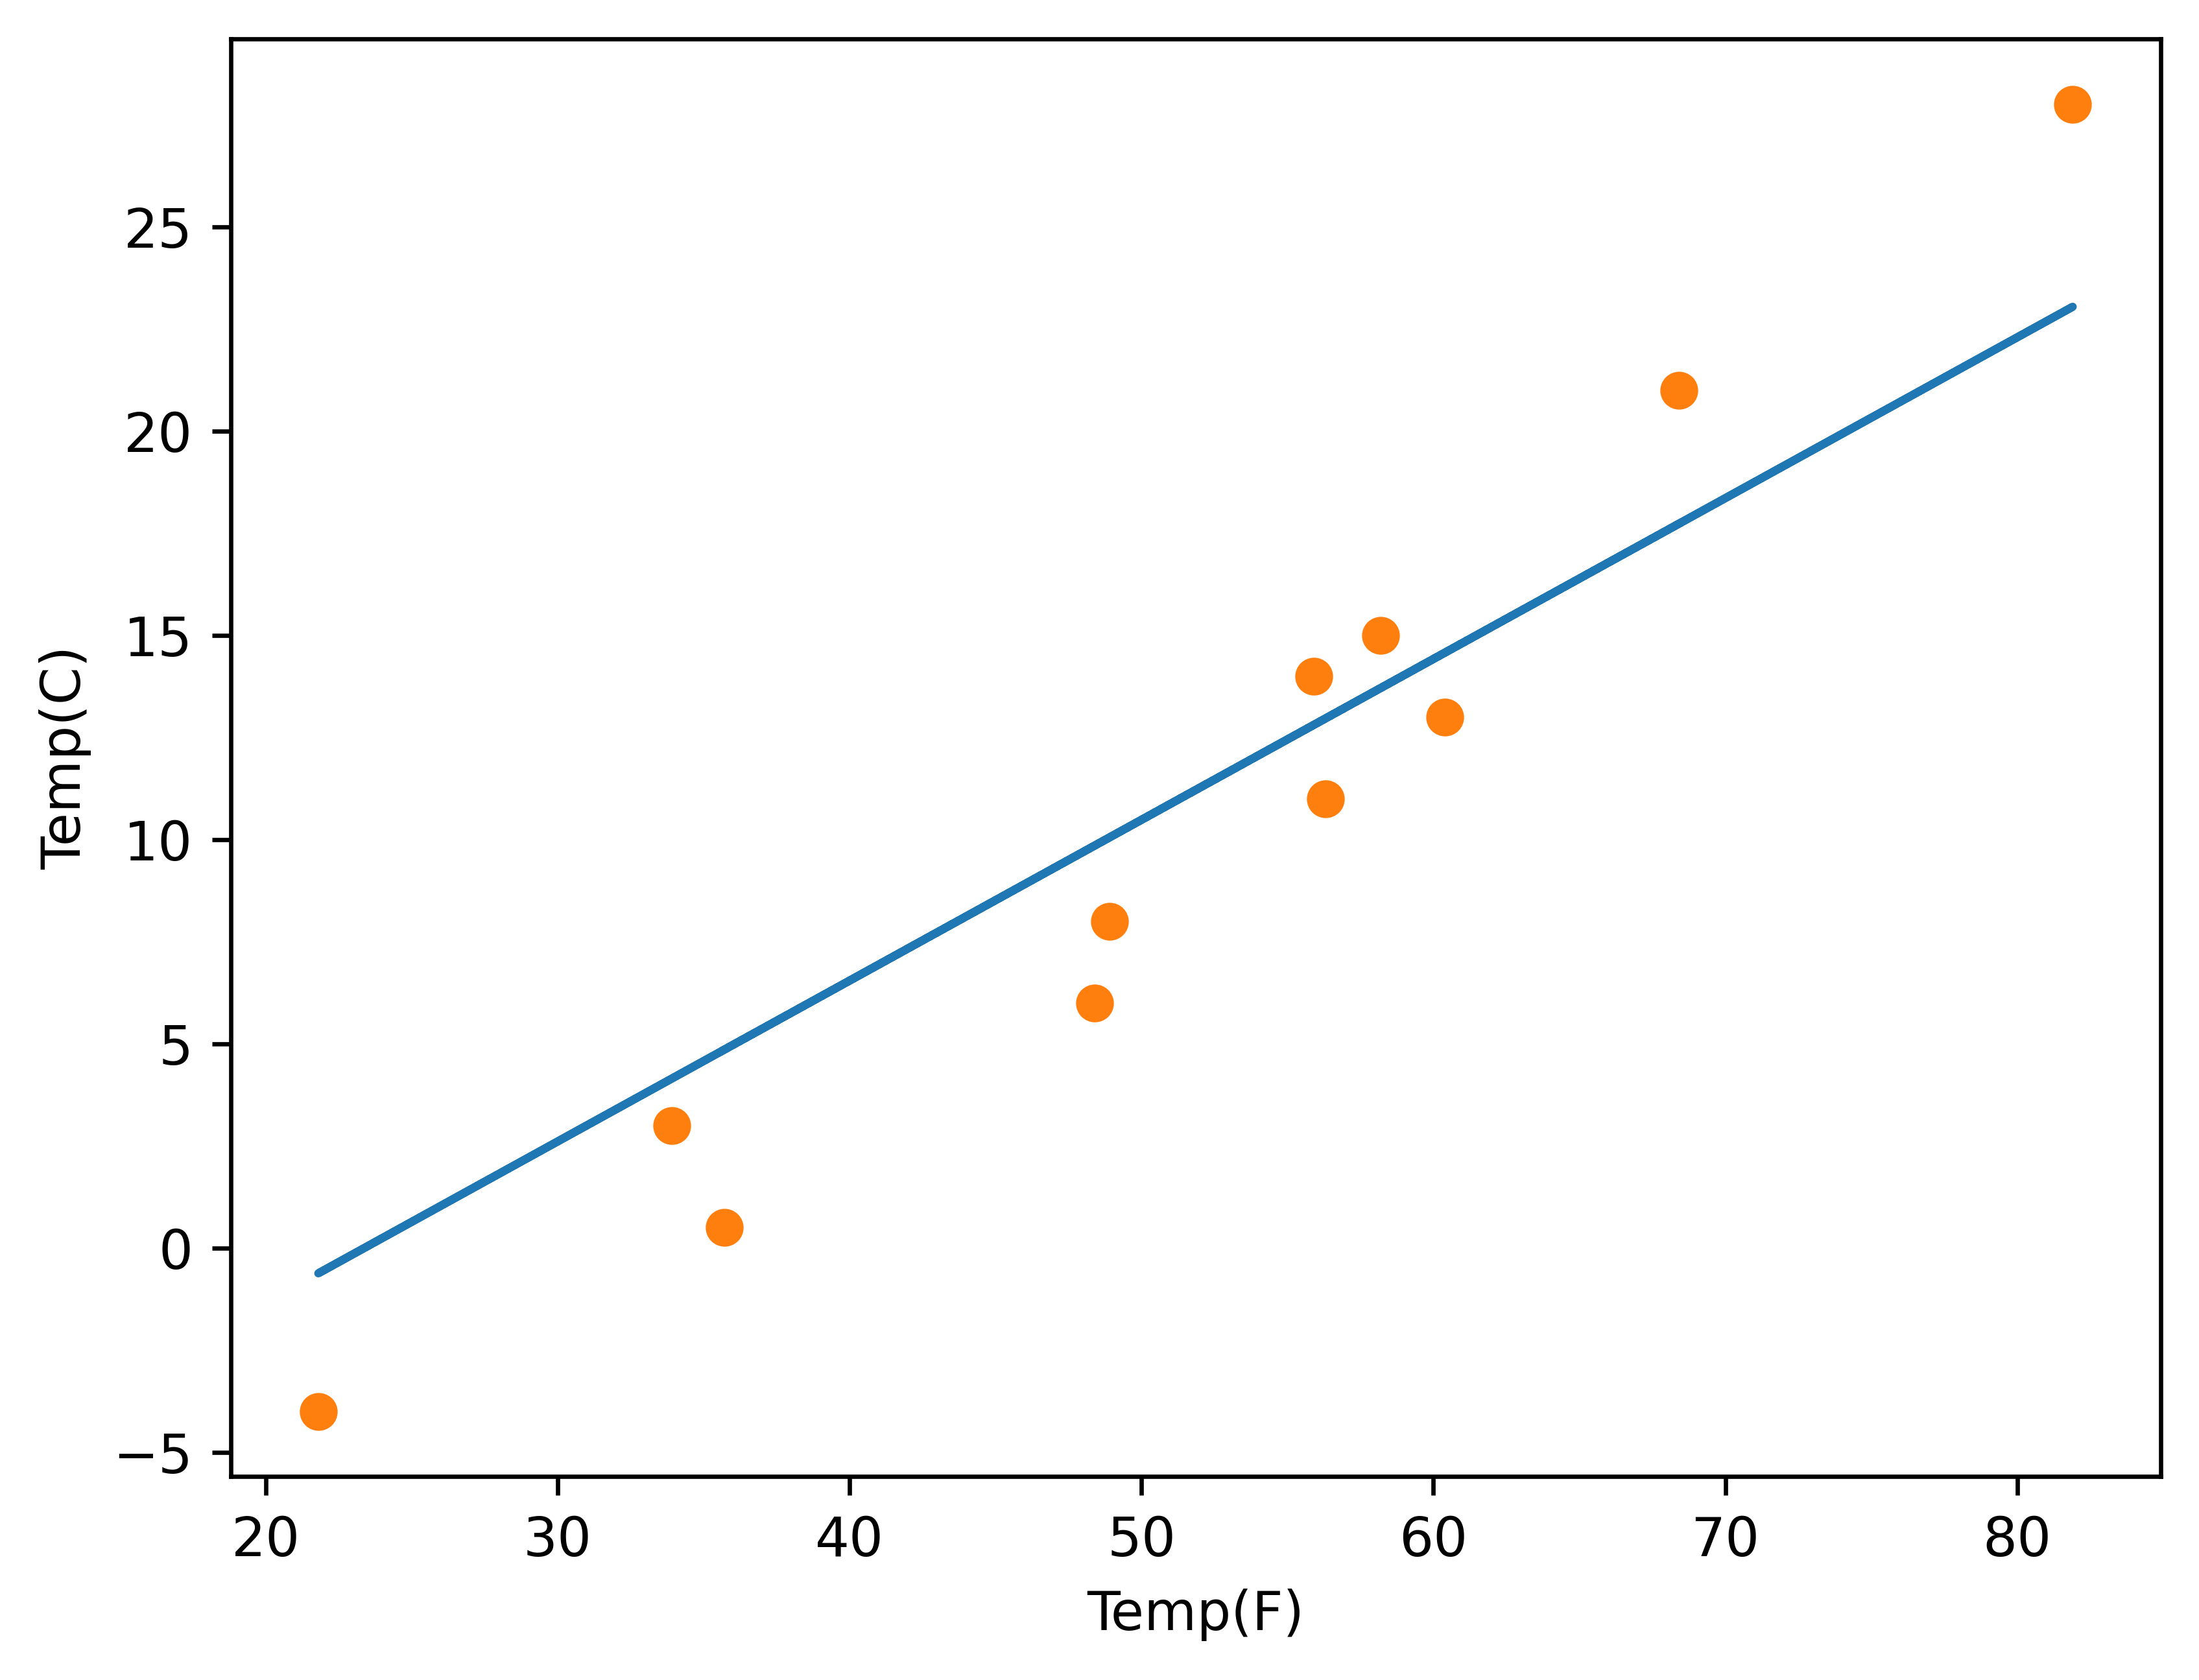

In [22]:
%matplotlib inline
from matplotlib import pyplot as plt

t_p = model(t_un, *params)

fig = plt.figure(dpi=600)
plt.xlabel("Temp(F)")
plt.ylabel("Temp(C)")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

인자 언패킹(argument unpacking) 파이썬 기법으로

*param은 params 요소를 개별 인자로 전달한다는 의미다.
- params[0]는 모델 함수의 두 번째 인자인 w에 해당합니다.
- params[1]는 모델 함수의 세 번째 인자인 b에 해당합니다.
---

파이썬(리스트/튜플전달)과는 달리 파이토치 텐서는 선두 차원을 따라 분할되는 인자 언패킹을 사용할 수 있다.

```
model(t_un, *params) = model(t_un, params[0], params[1]) 과 동일
```

# 5.5 파이토치의 자동미분: 모든 것을 역전파하라
**연쇄규칙** 을 사용하여 **미분을 역방향으로 전파**하는 방법을 통해 w와 b를 내부 파라미터로 가지는 **모델과 손실에 대한 합성 함수 기울기를 계산**했다.

기본전제: 다루는 모든 함수가 해석적으로 **미분 가능**해야 한다는 것.

미분이 가능한 경우-> 파라미터에 대해 **'손실값이 변하는 비율'**이라 부른 기울기를 단번에 계산 가능

모델이 수백만의 파라미터를 가져도, 미분만 가능하면 손실값의 기울기를 계산하고 미분에 대한 해석 가능한 표현식을 작성하여 단번에 계산이 가능하다.(하지만 이 작업은 고되다)






## 5.5.1 기울기 자동 계산
그리하여 파이토치 **자동미분(autograd)** 기능과 함께 파이토치 텐서가 등장.

파이토치 텐서는 어디서부터 왔고, 어떤 연산을 수행했는지 기억하기에 자연스럽게 미분을 최초 입력까지 연쇄적으로 적용해 올라갈 수 있다.

-> 미분을 **수동으로 도출할 필요가 없으며** 순방향 식이 주어진다면 복잡하게 꼬여 있더라도 입력 파라미터와 관련해 **표현식에 대한 기울기를 자동으로 제공.**

### 자동미분 적용하기


In [23]:
# 자동미분을 사용해 온도계 보정 코드 작성, 동작 확인
# 손실 함수와 모델
def loss_fn(t_p, t_c):
  squared_diffs = (t_p - t_c)**2
  return squared_diffs.mean()

def model(t_u, w, b):
  return w * t_u + b

In [24]:
# 파라미터 텐서 다시 초기화
params = torch.tensor([1.0, 0.0], requires_grad=True)

### 미분 속성 사용하기
`requires_grad=True` 인자는 params에 가해지는 연산의 결과로 만들어지는 **모든 텐서를 이은 전체 트리를 기록**하라고 파이토치에게 요청한다

즉, params를 조상으로 둔 텐서는 params로 부터 해당 텐서가 만들어지기까지 그 사이에 있는 **모든 함수에 접근할 권한**을 가진다

그래서 **미분 가능한 경우 미분값은 params 텐서의 grad 속성으로 자동 기록**된다.

In [25]:
# 모든 파이토치 텐서는 grad 속성을 가진다(주로 값은 None)
params.grad is None

True

In [26]:
# 이 값을 얻으려면 requires_grad=True로 지정
# 모델을 호출해 손실값을 구하고 loss 텐서에 대해 backward를 호출
loss = loss_fn(model(t_u, *params), t_c)
loss.backward()

params.grad

tensor([4517.2969,   82.6000])

이제 params의 grad는 params의 각 요소에 대한 손실값의 미분을 포함.

loss를 계산할 때, 실제 계산을 수행하는 이외 파라미터 w와 b가 기울기를 요구하는 경우, 파이토치는 **연산을 노드로 하는 자동미분 그래프**를 만든다.

이후 `loss_backward()`를 호출할 때, 파이토치는 그림 아래쪽에서 왼쪽 화살표 방향으로 그래프를 거꾸로 따라가면서 기울기 계산


.backward()는 PyTorch의 자동 미분 기능을 트리거하여 계산 그래프를 역방향으로 탐색하며 손실 함수의 파라미터에 대한 미분값을 계산하고, 이를 각 파라미터 텐서의 .grad 속성에 저장하는 역할을 합니다. 이는 모델 학습 과정에서 파라미터를 업데이트하기 위한 필수적인 단계

### 미분 함수 누적하기
파이토치는 연쇄적으로 연결된 함수들(계산그래프)을 거쳐 손실에 대한 미분을 계산하고, 값을 텐서의 grad 속성에 누적한다.

*저장이 아니라 *누적인 것을 기억하자.(파라미터 조정을 위해 사용한 후에는 기울기를 명시적으로 다시 0으로 초기화가 필요)

**누적의 문제**: 앞서 backward가 호출되었다면 손실이 다시 계산되고 backward가 다시 호출되고~계산 되었던 기존값에 누적되어 부정확한 기울기값을 초래한다.

**해결방안**: 각 반복문에서 **명시적으로 기울기를 0으로 초기화**한다(zero_메소드 사용)

In [27]:
if params.grad is not None:
  params.grad.zero_()

기울기를 자동으로 초기화하는 것보다 명시적으로 설정해줘야 복잡한 모델에서 기울기를 구할 때 더 유연하게 제어가 가능하기 때문

In [28]:
# 자동미분을 적용한 훈련 코드
def training_loop(n_epochs, learning_rate, params, t_u, t_c): # 에포크, 학습률, 파라미터, 보정값, 섭씨온도값
  for epoch in range(1, n_epochs + 1):
    if params.grad is not None:
      params.grad.zero_() # 명시적으로 기울기 0 초기화

      t_p = model(t_u, *params)
      loss = loss_fn(t_p, t_c) # 손실함수
      loss.backward()

      with torch.no_grad(): # 순방향 그래프에 부가적인 엣지를 더할 필요가 없다는 의미
        params -= learning_rate * params.grad

      if epoch % 500 == 0:
        print('Epoch %d, Loss %f' % (epoch, float(loss)))

  return params

해당 코드에서 두 가지 특징:
1. 파이썬 with로 파라미터 조정이 no_grad 콘텍스트 안에서 이뤄지도록 둘러쌈
- 자동 미분 기능은 이 부분을 신경쓰지 않음. 순방향 그래프 사용, 말단 노드 params를 얻음.
2. params를 덮어쓰며 조정한다.(params 텐서를 계속 유지하며 조정할 값을 뽑아낸다)
- 자동미분 사용 시 값을 덮어쓰며 조정하지 않는다.(역방향 전달시 변수 값을 바꿔야 할 수 있기에)
- 새로운 텐서를 변수 이름에 할당하여 파라미터를 변경하지 않는 방식은 옵티마이저에 파라미터를 등록할 때 매우 중요한 부분이 된다.

In [29]:
training_loop(
    n_epochs = 5000,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0], requires_grad=True),  # requires_grad=True가 핵심
    t_u = t_un,  # 여기서 t_u 대신 정규화된 t_un 사용
    t_c = t_c)

tensor([1., 0.], requires_grad=True)

## 5.5.2 골라쓰는 옵티마이저
모델이 복잡해질 경우, 수렴을 위해 사용할 수 있는 여러가지 최적화 전략과 기법이 존재.

최적화 지원으로 모델에 대해 모든 파라미터를 직접 조정하는 작업을 대신 해주는 `torch`에는 `optim` 서브 모듈이 있는데 다양한 최적화 알고리즘 구현 클래스를 찾아볼 수 있다.

In [30]:
import torch.optim as optim

dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 'lr_scheduler',
 'swa_utils']

모든 옵티마이저는 `zero_grad`와 `step`라는 두 가지 메소드 제공.

`zero_grad`는 옵티마이저 생성자에 전달됐던 파라미터의 모든 grad 속성값을 0으로 만든다.

`step`은 옵티마이저별로 구현된 최적화 전략에 따라 파라미터 값을 조정한다.

### 경사 하강 옵티마이저 사용하기

In [31]:
# params를 만들고 경사 하강 옵티마이저 인스턴스 생성
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

`SGD`는 확률적 경사 하강의 약자로 실제 순정 버전의 경사 하강과 완전히 동일하다.

SGD의 기울기는 `미니 배치`라고 불리는 여러 샘플 중에서 임의의 일부에 대해 평균을 계산해 얻기에 `확률적`이라는 말을 사용한다.

다만, 옵티마이저는 손실값이 모든 샘플로부터 얻은 것(순정)인지 일부를 임의로 선택해 얻은 것(확률적)인지 모르기에 알고리즘적으로 두 경우가 동일하다.

In [32]:
# 옵티마이저 실행
t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)
loss.backward()

optimizer.step()

params

tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)

직접 건드리지 않아도 step 호출을 통해 params가 알아서 조정한다.

params.grad를 보고 params에서 grad에 learning_rate를 곱한것 만큼 값을 빼서 조정한다.

추가적으로 역전파 과정에서 기울기 값은 말단노드에 계속 누적되며 경사 하강이 일어나기에 zero_grad를 추가하여 루프에 넣자

In [33]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)

optimizer.zero_grad() # 추가
loss.backward()
optimizer.step()

params

tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)

In [34]:
# 훈련 루프도 맞춰보자.
def training_loop(n_epochs, optimizer, params, t_u, t_c): # 에포크, 학습률, 파라미터, 보정값, 섭씨온도값
  for epoch in range(1, n_epochs + 1):
      t_p = model(t_u, *params)
      loss = loss_fn(t_p, t_c) # 손실함수

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if epoch % 500 == 0:
        print('Epoch %d, Loss %f' % (epoch, float(loss)))

  return params

In [35]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    params = params,
    t_u = t_un,
    t_c = t_c)

Epoch 500, Loss 7.860120
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

### 다른 옵티마이저 테스트하기
다른 옵티마이저를 더 테스트 해보려면 SGD 대신 *Adam* 을 사용하여 다른 옵티마이저를 인스턴스로 만들어보자.

아담은 **학습률이 동적으로 변하는 좀 더 섬세한** 옵티마이저로,

파라미터의 비율 조정도 덜 영향을 받아 정규화되지 않은 **원래 입력 t_u**를 사용, **학습률을 1e-1**로 올려도 지장없이 학습을 수행한다.

In [36]:
# adam 옵티마이저 사용
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate) # Adam 옵티마이저 클래스

training_loop(
    n_epochs = 2000,
    optimizer = optimizer,
    params = params,
    t_u = t_u, # 원래 값 t_u
    t_c = t_c)

Epoch 500, Loss 7.612900
Epoch 1000, Loss 3.086698
Epoch 1500, Loss 2.928578
Epoch 2000, Loss 2.927646


tensor([  0.5367, -17.3021], requires_grad=True)

## 머신러닝 내부 동작
기울기를 추정하기 위한 역전파, 자동미분, 모델 가중치의 최적화를 경사 하강이나 다른 옵티마이저를 통해 수행한다.

이 훈련 샘플을 어떻게 부분 부분으로 나눌지 자동미분을 더 잘 다루는 법으로 넘어간다.

## 5.5.3 훈련, 검증, 과적합
**적응성이 높은 모델**은 많은 파라미터를 사용하여 주어진 데이터 포인트에 대해 **손실을 최소화**하도록 학습되지만 이 상태가 데이터 포인트 사이나 데이터 포인트에서 **벗어난 경우**에 대해서도 **잘 동작**하는지 **보장할 수는 없다**.

옵티마이저에게 **손실을 최소화**하라고 요청->손실을 구하거나 음의 기울기를 따라 내려갈 때 사용했던 데이터와는 다른 별개의 데이터를 사용하면 **기대했던 것보다 높은 손실값**을 얻을 수 있다.=> **과적합** 현상

### 과적합
과적합을 방지하기 위해 대응하는 방법 중 하나: 과적합이 일어날 수 있음을 먼저 인지하기.

데이터 일부(검증셋), 남은 데이터(훈련셋)로 모델을 맞춘다.

손실은 한 번은 훈련셋에 대해 구하고, 한 번은 검증셋에 대해 구한다.

이는 모델이 데이터에 맞추는 작업이 잘 끝내기 위해 준비하는 과정이다.

### 훈련 손실 평가하기
훈련 손실값은 모델이 훈련셋에 얼마나 잘 맞춰졌는지, 모델이 데이터에 있는 필요한 정보를 찾아 처리하기 충분한지 알려준다.

심층신경망은 충분한 수의 파라미터가 제공된다면 매우 복잡한 함수에도 근사할 수 있다.

파라미터 수가 적다면 근사할 수 있는 함수는 더욱 단순한 모양에 그친다.

훈련손실이 줄어들지 않았다면, 데이터에 비해 **모델이 너무 단순**할 가능성이 있다.

혹은 출력을 설명할 만한 데이터가 아닐 수도 있다(온도계가 아니라 기압계였다면 기압으로 온도를 예측하는 경우)

### 검증셋으로 일반화하기
검증셋에 대한 손실이 훈련셋에서처럼 **줄어들지 않는 것으로 평가**된다면 모델이 훈련을 통해 바라본 **샘플에 대해서는 맞춰지며 발전**하지만 훈련셋을 **벗어난 샘플**에 대해서는 일반화되지 않는다.

훈련 때 보지 않았던 **데이터 포인트에 대해 평가**->손실함수의 값은 **높게** 나온다.

(온도계 샘플 예시) 선형 함수보다 좀 더 복잡한 함수를 사용하며 데이터에 맞춘 가정:

세세하게 구분 가능한 다항식, 큰 신경망 이라면 **각 데이터 포인트에 대해 손실이 증가하지 않는** 상황이기 떄문에, 훈련 데이터보다 **떨어져 있는 입력**에 대해서는 잘 처리할 방법이 없다.

#### 개선방법은?
1. 충분한 데이터 확인
사인파 형태 저빈도 규칙적 샘플링으로 데이터를 모았다면? 모델을 맞추기 어렵다.

2. 모델이 각 훈련 데이터에 대해 적합한 수준으로 맞춰질 수 있는지 여부
2-1. 손실 함수에 페널티항 을 두어 모델의 적합(데이터에 가까워지는 과정)이 더 천천히, 부드럽게 만들어지는 법

2-2. 입력 샘플에 노이즈를 더하는 것. 각 훈련 데이터 사이에 새로운 데이터 포인트를 인위적으로 만들고, 모델로 하여금 이 데이터에도 맞춰지도록 만드는 것

> 모델의 단순화: 데이터 사이에 존재하는 값을 적절하게 맞출 가능성이 높다.

### 상호 절충안:
1. 모델이 훈련을 위한 학습셋에 적합해질 만큼의 충분한 능력
2. 모델이 과적합을 방지할 수 있어야 함

-> 신경망 사이즈를 고르는 것: 먼저 적합될 때 까지 사이즈를 늘리고~과적합하지 않을 때까지 규모를 줄인다.



### 데이터셋 나누기
훈련셋과 검증셋으로 나누는 것을 먼저 t_u와 t_c를 같은 식으로 섞어(shuffling) 만들어진 텐서를 두 개로 나눈다.

In [37]:
# randperm 함수는 색인 순열을 찾기 위해 텐서 요소를 섞었을 때의 인덱스 리스트를 반환
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val] # 앞에까지 일부(훈련셋)
val_indices = shuffled_indices[-n_val:] # 뒤까지 일부(검증셋)

train_indices, val_indices

(tensor([ 1,  8,  5,  3,  7,  0, 10,  2,  6]), tensor([4, 9]))

In [38]:
# 인덱스 텐서를 얻었으니 데이터 텐서로부터 "훈련셋"과 "검증셋" 만들기
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u # -1.0~1.0 사이 정규화(t_un)
val_t_un = 0.1 * val_t_u # -1.0~1.0 사이 정규화(t_un)

In [39]:
# 훈련 루프 변경 X
# 각 에포크마다 부가적으로 검증셋에 대한 손실을 계산하여 과적합하고 있는지 파악하는 부분 추가
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
  for epoch in range(1, n_epochs + 1):
    train_t_p = model(train_t_u, *params) # train_t_u
    train_loss = loss_fn(train_t_p, train_t_c)

    val_t_p = model(val_t_u, *params) # val_t_u
    val_loss = loss_fn(val_t_p, val_t_c)

    optimizer.zero_grad()
    train_loss.backward() # 검증 데이터로는 학습하면 안되므로 val_loss.backward()가 없다.
    optimizer.step()

    if epoch <= 3 or epoch % 500 == 0:
      print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
            f" Validation loss {val_loss.item():.4f}")

  return params

In [40]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs = 3000,
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un, # (SGD 사용하므로 정규화 입력)
    val_t_u = val_t_un, # (SGD 사용하므로 정규화 입력)
    train_t_c = train_t_c,
    val_t_c = val_t_c)

Epoch 1, Training loss 89.6366, Validation loss 38.6392
Epoch 2, Training loss 44.9269, Validation loss 2.5454
Epoch 3, Training loss 37.1240, Validation loss 0.5562
Epoch 500, Training loss 6.6685, Validation loss 5.3562
Epoch 1000, Training loss 2.9650, Validation loss 6.1116
Epoch 1500, Training loss 2.4965, Validation loss 6.4033
Epoch 2000, Training loss 2.4372, Validation loss 6.5099
Epoch 2500, Training loss 2.4297, Validation loss 6.5482
Epoch 3000, Training loss 2.4288, Validation loss 6.5619


tensor([  5.4815, -17.4260], requires_grad=True)

훈련셋과 검증셋은 동일한 양이 아니다.

검증셋 은 **매우 작기** 때문에, **검증셋에서의 손실값은 의미 있을 수준** 정도.

결과에서 그래프상 검증 손실은 훈련 손실보다 크다는 사실(**검증손실>훈련손실**)

통상적으로 **모델이 훈련셋에 대해 더 잘 동작**하는 것은 정상.(훈련셋에 대해 파라미터가 생성하기 때문)

훈련의 목표: **훈련 손실과 검증 손실이 둘 다 줄어드는 형태**.
- 검증 손실이 훈련 손실에 매우 가깝게 다가가면서 두 값이 거의 같아지는 것이 이상적.

-> 이 형태는 모델이 데이터에 대해 **일반화된 학습을 지속적으로 진행**하는 것.

- 1) 반복 횟수가 많아질 수록 손실 값은 줄어드는 것 (이상적)
- 2) 1과 동일하나 손실 값이 미미하게 줄어드는 것 (받아줄만함(절대값차이))
- 3) 반복 횟수가 많아지지만 손실 값이 줄어들지 않는 것 (학습X)
- 4) 반복 횟수가 많아지지만 손실 값이 늘어나는 것 (과적합)




## 5.5.4 자동미분의 주의사항과 자동미분 끄기
훈련 루프에서 train_loss 에 대해서 backward를 호출한다(역전파 학습). 따라 역전파는 훈련셋에 대한 오차만 전파

검증셋은 훈련에서 사용하지 않았던 데이터에 대해 모델의 출력값 정확도를 독립적으로 평가하는 데 사용.

> 질문: "모델이 두 번 평가되고 있다 그러고 나서 backward가 호출된다면 자동미분이 이상해지지 않을까?"

> 답변: 그렇지 않다. 훈련 루프의 첫 줄은 train_t_p로부터 train_loss가 평가. 때문에 **train_t_u -> train_t_p -> train_loss 로 이어지는 연산 그래프** 생성

model이 val_t_u에 대해 평가 될 때에는 val_t_p와 val_loss 생성.

이 경우 **val_t_u -> val_t_p -> val_loss 별도의 연산 그래프** 생성.

model과 loss_fn 함수에 대해 **별개의 텐서가 각기 다른 연산 그래프를 만들기**에 괜찮다.


두 그래프가 **공유하는 유일한 텐서는 파라미터 텐서**다.

train_loss 에 대해 backward 호출 -> 첫 번째 그래프에 대해 backward 수행

train_t_u에서 만들어진 연산 그래프의 파라미터에 대해 train_loss의 미분을 누적.




**하지만** 실수로 **val_loss에 backward를 호출**하면 동일한 말단 노드인 파라미터 텐서에 대해 val_loss의 미분을 누적한다.

기울기를 명시적으로 0으로 초기화하지 않으면 기울기가 누적되서 **zero_grad를 사용**했는데, 이것도 비슷한 경우로 **train_backward() 호출**로 값이 기록된 params 텐서에 추가로 **기울기를 누적**해버린다.

즉, 훈련셋과 검증셋 모두에 대해 모델을 훈련시키는 셈.

> 그러면 왜 val_loss에 backward를 호출하지 않을까? 처음 연산 그래프를 만드는 이유는?

계산을 추적하지 않고 일반 함수처럼 Model과 loss_fn을 호출하면 될 것이라고 생각했지만,

그럼에도 최적화된 자동미분 그래프 생성에는 **검증 과정에는 생략해도 되는 비용**이 들어간다.

즉, 파라미터가 수백만 개에 이르는 모델이라면 **비용도 더 커진다.**

-> 그렇기에 파이토치는 `torch.no_grad` 콘텍스트 관리자를 통해 필요하지 않을 때 자동미분을 끌 수 있게 해준다.

큰 모델의 경우는 val_loss 텐서의 **`requires_grad` 속성을 통해 값이 원하는 대로 설정**되었는지 확인이 가능 하다.(지금 다루는 문제는 작기 때문에 이런 조정을 통해 속도나 메모리 사용 절감 등의 유의미한 이득을 보기는 어렵다))

In [41]:
# val_loss 텐서의 requires_grad 속성을 통해 값이 원하는 대로 설정
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
  for epoch in range(1, n_epochs + 1):
    train_t_p = model(train_t_u, *params)
    train_loss = loss_fn(train_t_p, train_t_c)

    with torch.no_grad():  # 콘텍스트 관리자
      val_t_p = model(val_t_u, *params)
      val_loss = loss_fn(val_t_p, val_t_c)
      assert val_loss.requires_grad == False # 블록 내 require_grad가 False로 설정을 강제한다는 상황 점검

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

`set_grad_enabled` 를 통한 콘텍스트 설정으로는 **autograd를 켤치 혹은 끌지**를 제어한다.

불리언 표현으로는 **현재 훈련 모드인지, 추론 모드**인지를 나타낸다.

`calc_forward` 함수를 정의하고 데이터를 입력받아 model과 loss_fn을 실행하되,

is_train 인자에 따라 **자동미분의 사용 여부를 설정**할 수도 있다.





In [42]:
# calc_forward, is_train
def calc_forward(t_u, t_c, is_train):
  with torch.set_grad_enabled(is_train):
    t_p = model(t_u, *params)
    loss = loss_fn(t_p, t_c)
  return loss

# 5.6 결론
1.   기계가 예제를 통해 어떻게 학습하는가?
2.   나머지 부분은 모델을 데이터에 맞추기 위한 최적화 메커니즘
3.   불필요하며 복잡한 요소는 제거하여 동작하는 부분을 볼 수 있도록 단순한 모델 선정
4.   다음 6장에는 신경망 훈련에 무엇이 필요한지를 더 간단히 이해해보자.

